# **PYTHON FOR COMPUTER VISION**

## **Phần 1: Dữ liệu ảnh số (Digital Images)**

### **1. Bản chất kỹ thuật của Dữ liệu ảnh số**
Khi ánh sáng đi qua ống kính camera, cảm biến ảnh sẽ thu nhận các photon ánh sáng và chuyển đổi chúng thành tín hiệu điện (analog). Sau đó, bộ chuyển đổi ADC (Analog-to-Digital Converter) sẽ thực hiện hai bước: 
1. Lấy mẫu (Sampling) theo lưới tọa độ không gian
2. Lượng tử hóa (Quantization) các mức điện áp thành những giá trị số nguyên rời rạc. Các điểm số hóa này được gọi là Điểm ảnh (Pixels - Picture Elements).

Trong Python, một bức ảnh được số hóa sẽ được biểu diễn và lưu trữ dưới dạng một mảng đa chiều (N-dimensional array).

#### **1.1. Kiểu dữ liệu và Không gian giá trị**
Mỗi pixel mang một giá trị số học đại diện cho cường độ sáng. Tiêu chuẩn phổ biến nhất trong xử lý ảnh thông thường là lưu trữ dưới định dạng Số nguyên không âm 8-bit (uint8 - Unsigned Integer 8-bit).
- Không gian lưu trữ: 2^8 = 256 mức độ.
- Miền giá trị: Trải dài từ 0 (Tối đen hoàn toàn) đến 255 (Sáng chói cực đại).

#### **1.2. Phân loại cấu trúc Ma trận ảnh**
- Ảnh xám (Grayscale Image): 
    - Là một Ma trận 2D. 
    - Kích thước mảng được định nghĩa bởi một tuple (H, W), trong đó H (Height) là số lượng hàng và W (Width) là số lượng cột.
- Ảnh màu (Color Image): 
    - Là một Mảng 3D. 
    - Kích thước mảng được định nghĩa bởi (H, W, C). Chiều sâu C (Channels) đại diện cho các kênh màu. Với ảnh màu tiêu chuẩn, C = 3 tương ứng với 3 kênh quang phổ cơ bản.

---

### **2. Thư viện OpenCV**
OpenCV (Open Source Computer Vision) là thư viện tiêu chuẩn để xử lý thị giác máy tính. Trong Python, thư viện được gọi qua module `cv2`.

#### **2.1. Nạp và Xuất dữ liệu**
- Đọc dữ liệu vào RAM: ```cv2.imread(filepath, flag)```
    - filepath: đường dẫn của ảnh
    - flag = 1 (Mặc định): Nạp ảnh màu (Mảng 3D).
    - flag = 0: Tự động chuyển đổi thành ảnh xám (Ma trận 2D). Việc này giúp giảm 2/3 dung lượng bộ nhớ và thường dùng làm bước tiền xử lý cho các thuật toán không cần đặc trưng màu (như nhận diện biên cạnh).
- Xuất dữ liệu ra tệp: ```cv2.imwrite(filename, image_matrix)```

In [1]:
import cv2

In [9]:
image_matrix = cv2.imread('./images/00-puppy.jpg', 0)
image_matrix

array([[85, 87, 88, ..., 26, 26, 26],
       [85, 86, 86, ..., 26, 26, 26],
       [85, 84, 84, ..., 26, 26, 26],
       ...,
       [25, 26, 26, ..., 27, 28, 28],
       [26, 26, 25, ..., 27, 28, 28],
       [26, 25, 25, ..., 27, 28, 28]], dtype=uint8)

In [ ]:
cv2.imwrite('./images/00-puppy-out.jpg', image_matrix)

True

#### **2.2. Hiển thị ảnh**

Sử dụng thư viện Matplotlib.
- Các thư viện hiển thị đồ họa hiện đại (như Matplotlib) tổ chức kênh màu theo trình tự: Red (0) - Green (1) - Blue (2).
- Tuy nhiên, OpenCV lại mặc định nạp và lưu trữ ảnh màu theo hệ BGR: Blue (0) - Green (1) - Red (2).

Vì vậy, nếu sử dụng các thư viện khác để hiển thị ảnh đọc từ OpenCV, luôn thực hiện chuyển đổi không gian màu.

In [21]:
image_matrix = cv2.imread('./images/00-puppy.jpg')

In [13]:
image_rgb = cv2.cvtColor(image_matrix, cv2.COLOR_BGR2RGB)

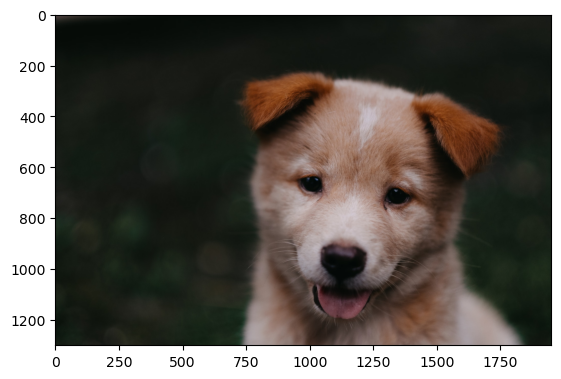

In [16]:
import matplotlib.pyplot as plt

plt.imshow(image_rgb)

(-0.5, 1949.5, 1299.5, -0.5)

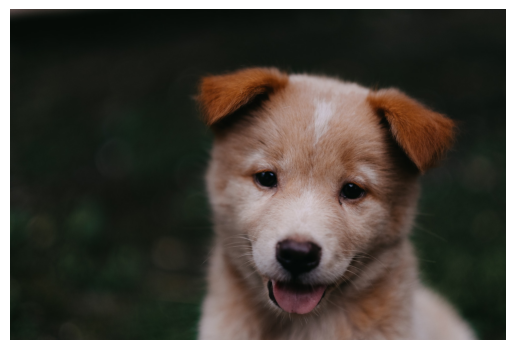

In [24]:
plt.imshow(image_rgb)
plt.axis('off')

### **3. Các thao tác trên Ma trận không gian ảnh**

#### **3.1. Truy cập và Chỉnh sửa giá trị Pixel đơn lẻ**
Để đọc hoặc thay đổi màu sắc tại một điểm ảnh cụ thể, ta truy cập trực tiếp vào chỉ mục tọa độ của ma trận theo quy tắc: `image[y, x]`.
- Đối với ảnh xám (Ma trận 2D): Kết quả trả về là một giá trị số nguyên đơn lẻ (kiểu uint8).
- Đối với ảnh màu (Mảng 3D): Kết quả trả về là một mảng gồm 3 phần tử tương ứng với cường độ của 3 kênh màu tại vị trí đó.

Lưu ý: Trong hình học, tọa độ điểm thường viết là (x, y) (trục hoành trước, trục tung sau). Tuy nhiên, trong ma trận NumPy, cấu trúc truy xuất là (Hàng, Cột), tương đương với trục tung trước, trục hoành sau: `image[y, x]`.

In [39]:
image = cv2.imread('./images/00-puppy.jpg')

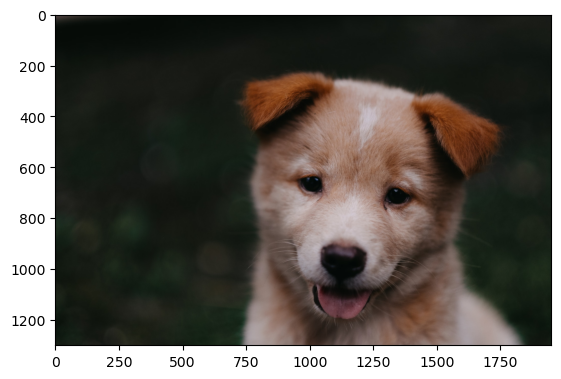

In [40]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [41]:
# 1. Đọc giá trị pixel tại hàng số 50, cột số 100
pixel_value = image[50, 100]
print(pixel_value)

[ 7 11  6]


In [42]:
# 2. Chỉnh sửa: Biến pixel tại tọa độ đó thành màu đỏ tuyệt đối trong hệ BGR
image[50, 100] = [0, 0, 255]

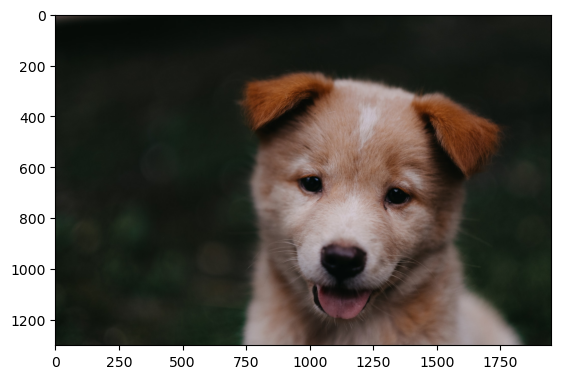

In [43]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

#### **3.2. Trích xuất Vùng quan tâm (ROI - Region of Interest)**
Sử dụng kỹ thuật Cắt mảng (Slicing) để cô lập vùng không gian chứa vật thể cần xử lý.

Cú pháp [start:end]: lấy các phần tử từ chỉ mục start đến chỉ mục end - 1 (loại trừ phần tử tại vị trí end).

In [44]:
roi = image[100:400, 250:550]

In [ ]:
image[100:400, 250:550] = [0, 0, 255]

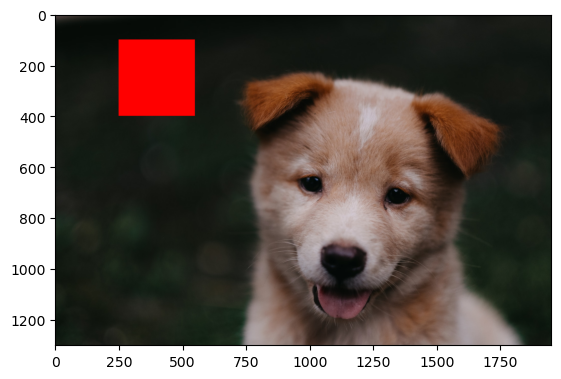

In [46]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

#### **3.3. Hoán đổi kênh màu**

**a) Đảo kênh màu BGR sáng RGB**

In [47]:
image = cv2.imread('./images/00-puppy.jpg')

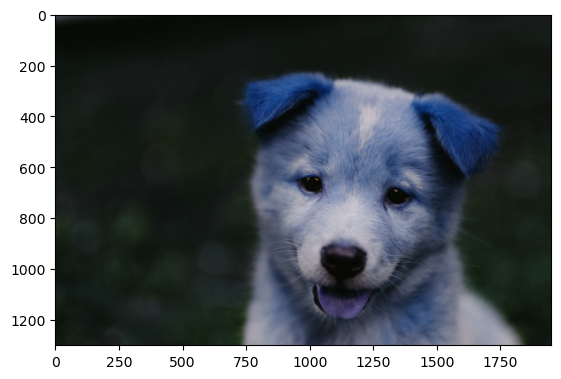

In [50]:
plt.imshow(image)

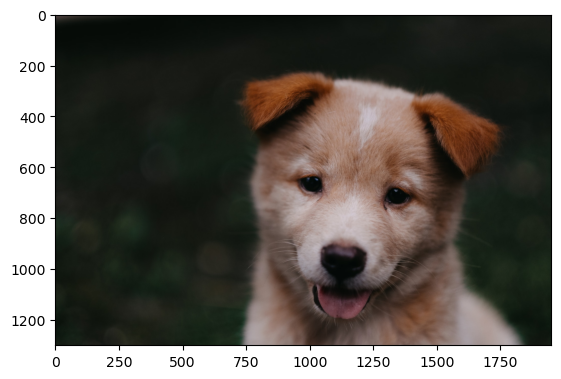

In [48]:
# 1) Dùng hàm convert color từ thư viện cv2
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

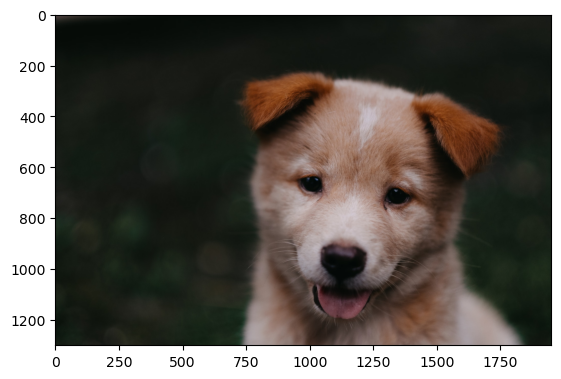

In [49]:
# 2) Đảo chỉ mục
# Cú pháp: image[tất cả hàng, tất cả cột, đảo ngược trục kênh]
plt.imshow(image[:, :, ::-1])

**b) Tách lấy 1 kênh màu**

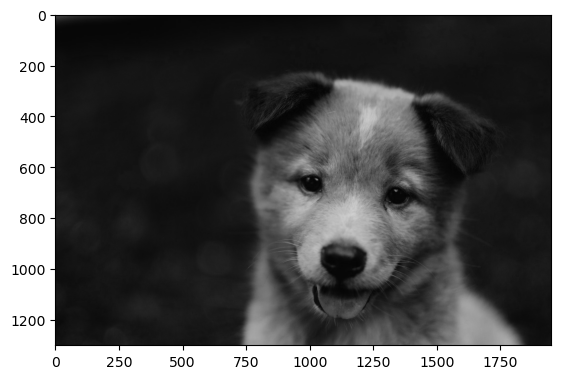

In [56]:
blue_channel = image[:, :, 0]
plt.imshow(cv2.cvtColor(blue_channel, cv2.COLOR_BGR2RGB))

**c) Cô lập kênh màu**
- Chỉ hiển thị màu blue.

=> Gán giá trị 0 cho 2 màu còn lại.

In [ ]:
only_blue_visible = image.copy()
only_blue_visible[:, :, 1] = 0
only_blue_visible[:, :, 2] = 0

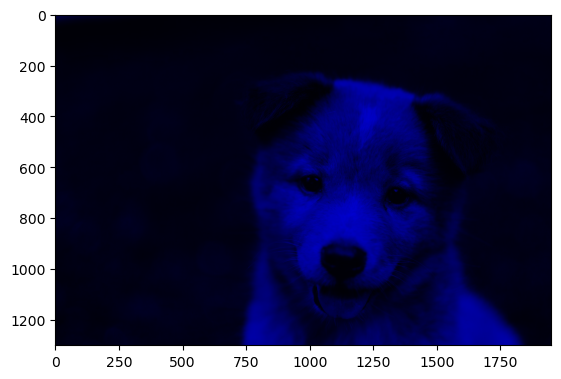

In [58]:
plt.imshow(cv2.cvtColor(only_blue_visible, cv2.COLOR_BGR2RGB))

In [59]:
only_blue_visible.shape

(1300, 1950, 3)

### **4. Các biến đổi hình học cơ bản**

#### **4.1. Thay đổi kích thước (resize)**

In [60]:
image = cv2.imread('./images/00-puppy.jpg')
image.shape

(1300, 1950, 3)

In [61]:
# 1. Ép về Kích thước Tuyệt đối (Absolute Resizing)
# Tham số truyền vào là (Rộng, Cao)
resized_img = cv2.resize(image, (800, 600))
resized_img.shape

(600, 800, 3)

In [62]:
# 2. Thay đổi theo Tỷ lệ phần trăm (Relative Scaling)
# Tham số truyền vào là hệ số scale (fx, fy)
# Thu nhỏ bức ảnh còn 50% so với gốc
scaled_img = cv2.resize(image, (0, 0), fx=0.5, fy=0.5)
scaled_img.shape

(650, 975, 3)

#### **4.2. Thuật toán Nội suy (Interpolation)**
Khi ta thu nhỏ hoặc phóng to một bức ảnh, hệ thống phải thực hiện thao tác xóa bớt pixel (khi thu nhỏ) hoặc tự "vẽ" thêm các pixel mới (khi phóng to). Thuật toán để tính toán màu sắc cho các pixel mới này gọi là Nội suy (Interpolation).

- Thu nhỏ ảnh (Shrinking): `cv2.INTER_AREA`
    - Thuật toán lấy trung bình các điểm ảnh, giúp ảnh thu nhỏ không bị răng cưa hay mất nét.
- Phóng to ảnh (Zooming/Enlarging): 
    - `cv2.INTER_CUBIC`: chất lượng cao nhất, nhưng tính toán chậm
    - `cv2.INTER_LINEAR`: mặc định, cân bằng giữa tốc độ và chất lượng

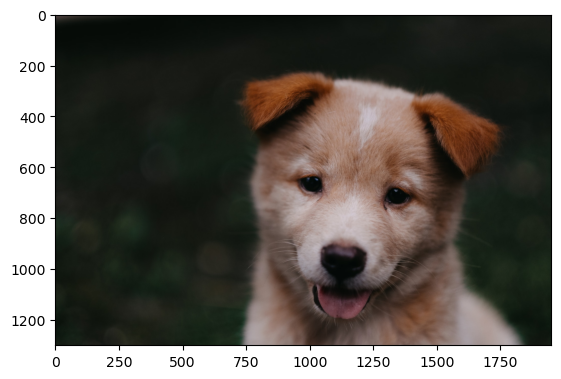

In [63]:
image = cv2.imread('./images/00-puppy.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

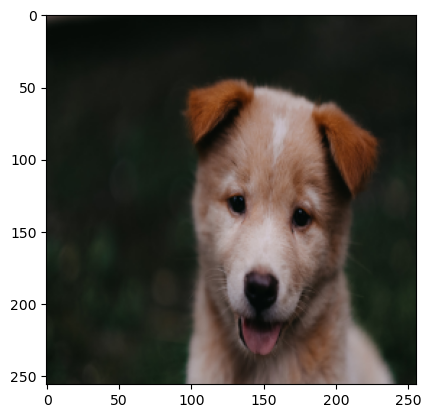

In [64]:
shrinked = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(shrinked, cv2.COLOR_BGR2RGB))

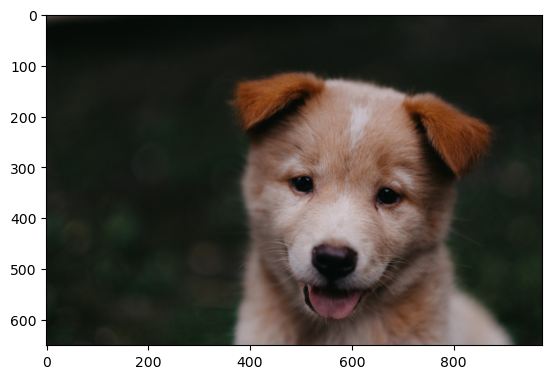

In [67]:
shrinked = cv2.resize(image, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(shrinked, cv2.COLOR_BGR2RGB))

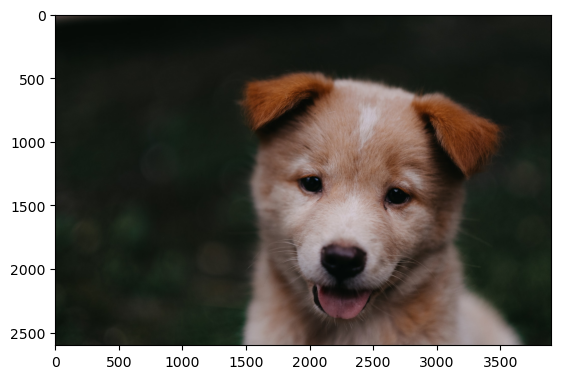

In [65]:
zoomed = cv2.resize(image, (0, 0), fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))

#### **4.3. Lật ảnh (Image Flipping)**
Trong huấn luyện mô hình AI nhận diện (image recognition) (ví dụ: nhận diện chó/mèo), một con chó quay mặt sang trái hay sang phải thì bản chất vẫn là một con chó. Kỹ thuật Lật ảnh giúp chúng ta nhân đôi số lượng dữ liệu một cách dễ dàng.

Sử dụng hàm `cv2.flip(src, flipCode)`:
- flipCode = 0: Lật theo trục X (Lật dọc - Up/Down).
- flipCode = 1: Lật theo trục Y (Lật ngang - Trái/Phải).
- flipCode = -1: Lật qua cả 2 trục (Tương đương xoay 180 độ).

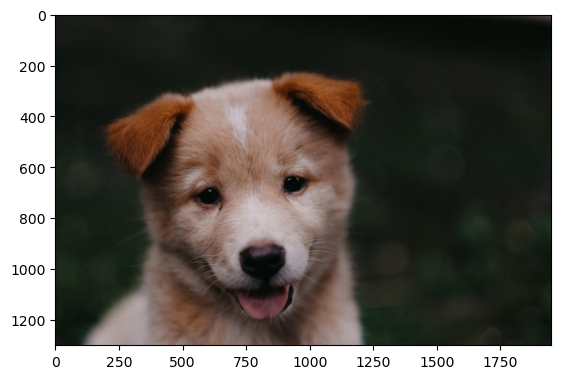

In [69]:
flipped_img = cv2.flip(image, 1)
plt.imshow(cv2.cvtColor(flipped_img, cv2.COLOR_BGR2RGB))

### **5. Đồ họa Máy tính trên Ma trận**
Ví dụ: Trong bài toán phát hiện vật thể (Object Detection), mô hình AI chỉ trả về các con số tọa độ dạng (x_min, y_min, x_max, y_max) của vật thể được phát hiện. 

Chúng ta cần vẽ hình chữ nhật để bao quanh vật thể (người đi bộ, xe cộ, khuôn mặt) giúp người dùng quan sát được AI đang phát hiện đối tượng ở vị trí nào.

**a) Khởi tạo khung vẽ**

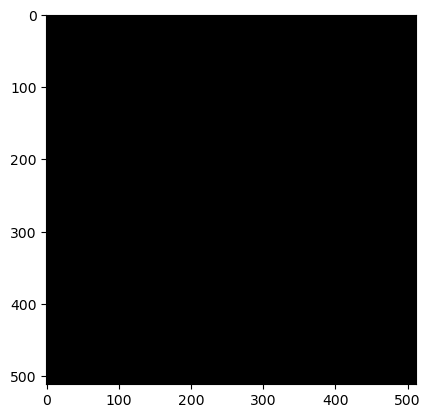

In [88]:
import numpy as np
import cv2

# Tạo ma trận 3D kích thước 512x512 với 3 kênh màu, kiểu dữ liệu uint8
canvas = np.zeros(shape=(512, 512, 3), dtype=np.uint8)
plt.imshow(canvas)

**b) Vẽ đoạn thẳng**
- pt1 & pt2: Tọa độ điểm bắt đầu và điểm kết thúc của đoạn thẳng.
- thickness: Độ dày của nét vẽ (tính bằng pixel). Đoạn thẳng không có khái niệm tô đặc.

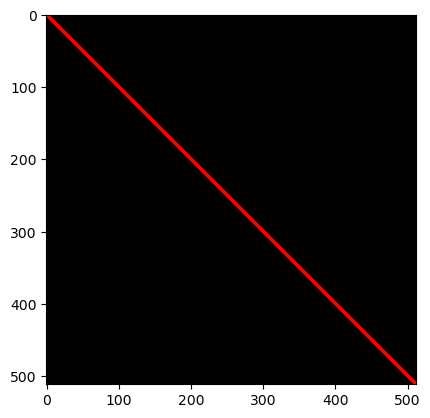

In [89]:
cv2.line(img=canvas, pt1=(0, 0), pt2=(512, 512), color=(255, 0, 0), thickness=3)
plt.imshow(canvas)

**c) Vẽ hình chữ nhật**

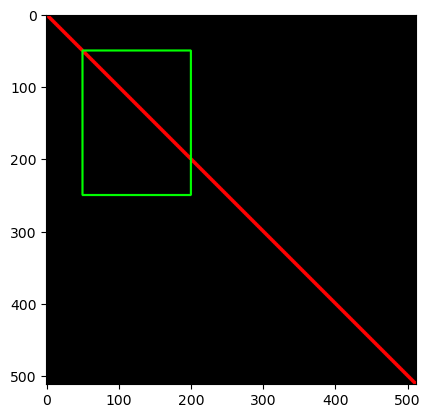

In [90]:
# Khung hình chữ nhật rỗng màu Xanh Lá
cv2.rectangle(img=canvas, pt1=(50, 50), pt2=(200, 250), color=(0, 255, 0), thickness=2)
plt.imshow(canvas)

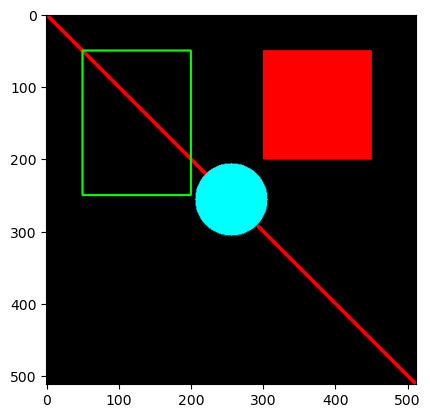

In [93]:
# Hình chữ nhật TÔ ĐẶC màu đỏ 
filled_rec = cv2.rectangle(img=canvas, pt1=(300, 50), pt2=(450, 200), color=(255, 0, 0), thickness=cv2.FILLED)
plt.imshow(filled_rec)

**d) Vẽ đường tròn**

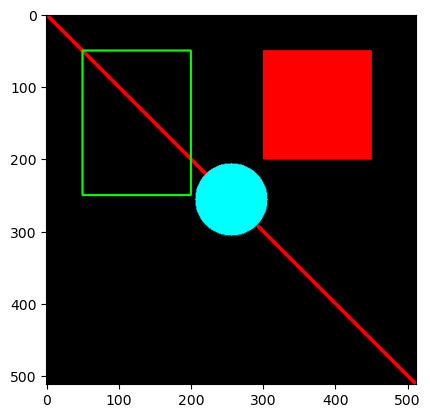

In [94]:
cv2.circle(img=canvas, center=(256, 256), radius=20, color=(0, 255, 255), thickness=-1)
plt.imshow(canvas)

**e) Ghi văn bản lên ảnh**
- org: Tọa độ điểm chân gốc phía bên trái (Bottom-left) nơi ký tự đầu tiên bắt đầu xuất hiện.
- fontFace: Phông chữ. Bắt buộc phải sử dụng các hằng số phông chữ vector được định nghĩa sẵn trong nhân OpenCV (như cv2.FONT_HERSHEY_SIMPLEX, cv2.FONT_HERSHEY_COMPLEX).
- fontScale: Hệ số thu phóng kích thước chữ (Kiểu số thực float).

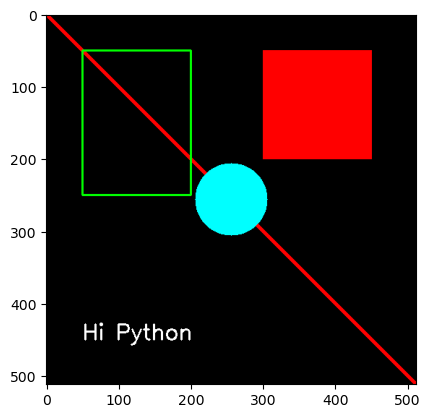

In [95]:
cv2.putText(img=canvas, text='Hi Python', org=(50, 450), 
            fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1.0, 
            color=(255, 255, 255), thickness=2)
plt.imshow(canvas)

## **Phần 2: Xử lý ảnh số**

### **1. Biến đổi Không gian Màu (Color Spaces)**
RGB là một không gian màu tuyến tính trộn lẫn cả Màu sắc (Chrominance) và Độ sáng (Luminance) vào cùng một giá trị.

Ví dụ: Nếu bức ảnh chụp một quả táo đỏ, nhưng một nửa quả táo bị bóng râm che khuất, giá trị RGB ở vùng sáng và vùng tối sẽ sai lệch nhau hoàn toàn. Điều này khiến máy tính cực kỳ khó khăn trong việc nhận diện vật thể dựa trên màu sắc. 

Để giải quyết, ta cần chuyển đổi bức ảnh sang một không gian màu mô phỏng cách mắt người cảm nhận ánh sáng: Hệ màu HSV (Hue - Saturation - Value).
- Hue (Sắc độ màu): Trải từ 0-179, quy định màu đó là đỏ, xanh hay vàng...
- Saturation (Độ bão hòa): Từ 0-255, quy định màu đó nhạt (gần với trắng) hay đậm rực rỡ.
- Value (Giá trị sáng): Từ 0-255, quy định độ chói của ánh sáng chiếu vào. 

In [96]:
import cv2
import numpy as np

# 1. Đọc ảnh gốc hệ BGR
img_bgr = cv2.imread('./images/apple.jpg')

In [97]:
# 2. Chuyển đổi từ không gian BGR sang HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

In [98]:
# 3. Tách mảng 3D thành 3 ma trận 2D độc lập (H, S, V)
h_channel = img_hsv[:, :, 0]
s_channel = img_hsv[:, :, 1]
v_channel = img_hsv[:, :, 2]

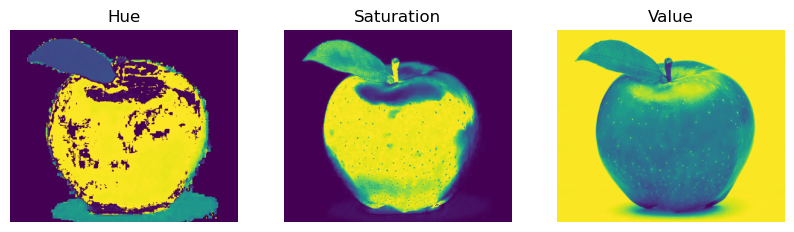

In [101]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1) 
plt.imshow(h_channel)
plt.title('Hue')
plt.axis('off')

plt.subplot(1, 3, 2) 
plt.imshow(s_channel)
plt.title('Saturation')
plt.axis('off')

plt.subplot(1, 3, 3) 
plt.imshow(v_channel)
plt.title('Value')
plt.axis('off')

plt.show()

### **2. Trộn ảnh và Mặt nạ Nhị phân (Blending & Masking)**
Bài toán: Chèn một logo có nền trắng vào một ảnh nền (background) sao cho phần nền trắng của logo bị xóa bỏ hoàn toàn, chỉ giữ lại phần ruột logo

1. Đọc ảnh và Xác định vùng cần chèn (ROI)
    - Đọc ảnh: Nạp ảnh nền (img_bg) và ảnh logo (img_logo).
    - Xác định ROI (Region of Interest)
2. Tạo Mặt nạ nhị phân (Mask): Đây là bước quan trọng nhất để phân tách nền trắng và ruột logo
    - Chuyển ảnh xám (img_gray): Chuyển logo từ ảnh màu sang ảnh trắng đen để dễ phân ngưỡng.
    - Tạo mask: Lệnh cv2.threshold biến tất cả các điểm ảnh có độ sáng từ 240 đến 255 (gần như trắng tinh) thành màu Trắng (255), các vùng còn lại (ruột logo) thành màu Đen (0).
    - Tạo mask_inv (Mặt nạ đảo ngược): Đảo ngược hoàn toàn mask. Lúc này, ruột logo biến thành màu Trắng (255) và nền xung quanh biến thành màu Đen (0).
3. Xử lý cắt ghép (Bitwise Operations)
    - OpenCV dùng phép toán logic toán học trên các điểm ảnh để "đục lỗ" và "cắt ảnh":
        - Đục lỗ ảnh nền (bg_punched): Lấy vùng ROI trên ảnh nền kết hợp với mask (nơi nền trắng của logo có giá trị 255). Kết quả là ảnh nền sẽ bị đục một cái lỗ đen có hình dáng đúng bằng hình ruột logo.
        - Cắt giữ lại ruột logo (fg_logo): Lấy ảnh logo gốc kết hợp với mask_inv (nơi ruột logo có giá trị 255). Kết quả là xóa sạch nền trắng vuông, chỉ giữ lại phần ruột logo có màu.
4. Hòa trộn và Thay thế (Blending)
    - Cộng ma trận: Sử dụng cv2.add để chồng ảnh fg_logo (ruột logo màu + nền đen) lên bg_punched (ảnh nền bị đục lỗ đen). Vì màu đen có giá trị bằng 0, nên khi cộng lại, phần ruột logo sẽ lấp đầy vào cái lỗ bị đục một cách hoàn hảo.
    - Ghi đè lại ảnh gốc

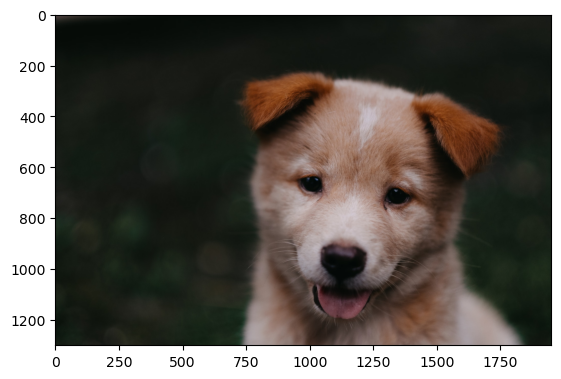

In [104]:
import cv2
import numpy as np

# 1. Đọc ảnh nền và ảnh logo
img_bg = cv2.imread('./images/00-puppy.jpg') 
cv2.resize(img_bg, (0, 0), fx=2.0, fy=2.0)
plt.imshow(cv2.cvtColor(img_bg, cv2.COLOR_BGR2RGB))

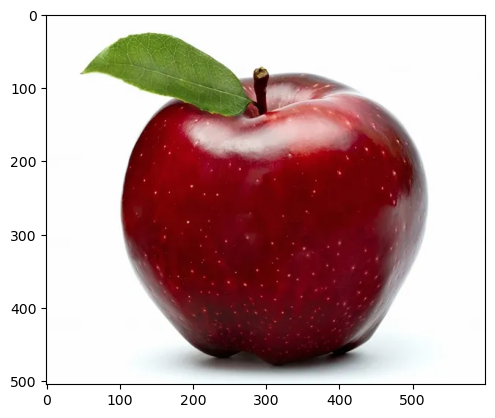

In [105]:
img_logo = cv2.imread('./images/apple.jpg')
cv2.resize(img_logo, (0, 0), fx=0.5, fy=0.5)
plt.imshow(cv2.cvtColor(img_logo, cv2.COLOR_BGR2RGB))

In [106]:
# 2. Xác định tọa độ và trích xuất vùng ROI trên ảnh nền (Góc trên cùng bên trái)
rows, cols, channels = img_logo.shape
roi = img_bg[0:rows, 0:cols]

In [107]:
# 3. Tạo mặt nạ nhị phân
img_gray = cv2.cvtColor(img_logo, cv2.COLOR_BGR2GRAY)
# Biến vùng nền trắng của logo thành 255 (Trắng), phần ruột logo thành Đen
_, mask = cv2.threshold(img_gray, 240, 255, cv2.THRESH_BINARY)
# Đảo ngược mặt nạ: Ruột logo thành 255 (Trắng), nền vuông thành 0 (Đen)
mask_inv = cv2.bitwise_not(mask)

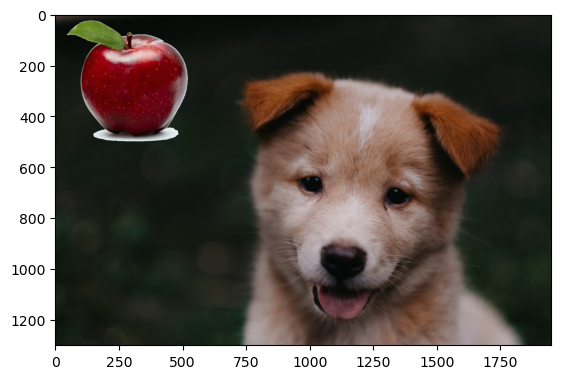

In [ ]:
# 4. Đục lỗ trên vùng ROI của ảnh nền (Xóa phần không gian sẽ đặt logo)
bg_punched = cv2.bitwise_and(roi, roi, mask=mask)

# 5. Khử nền vuông của ảnh logo (Chỉ giữ lại ruột logo màu)
fg_logo = cv2.bitwise_and(img_logo, img_logo, mask=mask_inv)

# 6. Hòa trộn mảnh ghép hoàn hảo bằng phép cộng ma trận
dst = cv2.add(bg_punched, fg_logo)

# 7. Thay thế vùng ROI cũ trên ảnh gốc bằng kết quả đã hòa trộn
img_bg[0:rows, 0:cols] = dst

plt.imshow(cv2.cvtColor(img_bg, cv2.COLOR_BGR2RGB))

### **3. Phân ngưỡng Phân đoạn (Image Thresholding)**
Ép toàn bộ dải màu xám chuyển về thành một ma trận chỉ chứa 2 giá trị cực đoan: Đen tuyệt đối (0) hoặc Trắng tuyệt đối (255).

Phân ngưỡng Toàn cục (Global Thresholding):
- Cơ chế: Cắt ngang bức ảnh bằng một hằng số duy nhất (ví dụ: 127). 
    - Nếu cường độ pixel $I(x,y) > 127$ thì biến thành 255, ngược lại biến thành 0.
    - Lệnh OpenCV: cv2.threshold()
    - Nhược điểm: Sẽ phá hỏng hoàn toàn bức ảnh nếu điều kiện ánh sáng không đồng đều (ví dụ: vùng giấy trắng bị bóng râm che khuất sẽ bị đánh đồng thành màu đen).

Phân ngưỡng Thích nghi (Adaptive Thresholding):
- Cơ chế: Khắc phục nhược điểm của phân ngưỡng toàn cục. 
    - Máy tính sẽ cầm một "khung cửa sổ" (Window) quét qua từng vùng nhỏ của ảnh. 
    - Tại mỗi vùng, nó tự tính trung bình cộng ánh sáng để thiết lập một ngưỡng (Threshold) riêng cho vùng đó.
    - Lệnh OpenCV: cv2.adaptiveThreshold()

### **4. Làm mờ và Làm mịn (Blurring & Smoothing)**
Nhiễu ảnh (Noise) thường là các điểm ảnh bị lệch pha chói sáng hoặc tối đen đột ngột do lỗi cảm biến quang học. Để là phẳng các nhiễu này, ta dùng phép Nhân chập 2D (Convolution) giữa ảnh gốc và một ma trận vuông gọi là Hạt nhân (Kernel).

1. Gaussian Blur (cv2.GaussianBlur): Các trọng số trong Kernel tuân theo hàm phân phối chuẩn hình chuông. Pixel ở tâm giữ trọng số lớn nhất và giảm dần ra xung quanh. Tạo ra hiệu ứng mờ nhòe tự nhiên, mô phỏng hiện tượng mất nét của ống kính.

2. Median Blur (cv2.medianBlur): Thay thế pixel ở tâm bằng Giá trị Trung vị của vùng lân cận. Đây là "Khắc tinh tuyệt đối" của Nhiễu muối tiêu (Salt and Pepper Noise).

3. Lọc Song hành (Bilateral Filter - cv2.bilateralFilter): Thuật toán ma thuật vừa làm mịn các vùng da (trị mụn), nhưng lại không làm mờ các đường biên sắc nét (như viền mắt, sống mũi) nhờ xét thêm khoảng cách về màu sắc.

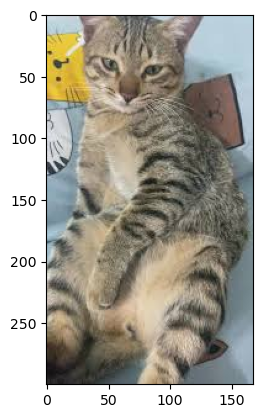

In [112]:
img = cv2.imread('./images/kitty.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

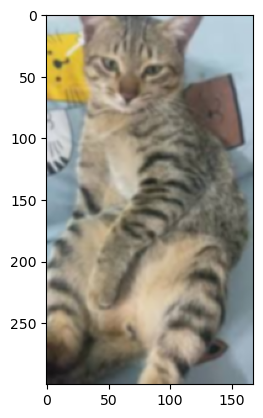

In [113]:
# 1. Gaussian Blur: Kích thước kernel (5,5), độ lệch chuẩn sigmaX = 0 (tự tính theo kernel)
gaussian = cv2.GaussianBlur(img, (5, 5), 0)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))

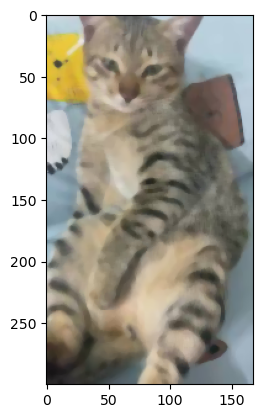

In [114]:
# 2. Median Blur: Kích thước kernel phải là số lẻ (ví dụ: 5)
median = cv2.medianBlur(img, 5)
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))

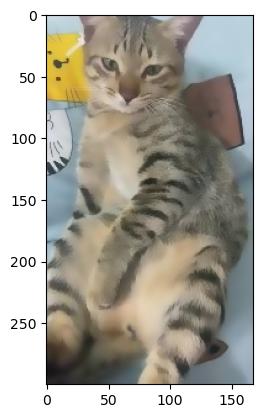

In [115]:
# 3. Bilateral Filter: d=9 (đường kính lân cận), sigmaColor=75, sigmaSpace=75
bilateral = cv2.bilateralFilter(img, 9, 75, 75)
plt.imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))

## **Phần 3: Phát hiện đối tượng (Object Detection)**

### **1. Khớp mẫu (Template Matching)**
Đây là phương pháp phát hiện đối tượng sơ khai nhất. 

Nguyên lý: Có một bức ảnh lớn (Ảnh gốc) và một bức ảnh nhỏ chứa vật thể cần tìm (Ảnh mẫu). Máy tính sẽ cầm bức ảnh mẫu quét qua từng pixel của ảnh gốc theo cơ chế cửa sổ trượt (Sliding Window). Tại mỗi vị trí, nó tính toán độ tương đồng (Correlation) giữa vùng ảnh gốc và ảnh mẫu.
- Lệnh thực hiện: cv2.matchTemplate(img, template, method)
- Sau đó dùng cv2.minMaxLoc() để tìm ra tọa độ đỉnh cao nhất (hoặc thấp nhất tùy phương pháp).

Nhược điểm: Template Matching rất kém linh hoạt. Nếu vật thể trong ảnh gốc bị phóng to, thu nhỏ (Scale) hoặc bị xoay nghiêng (Rotation) dù chỉ vài độ so với ảnh mẫu, thuật toán sẽ thất bại.

In [ ]:
# 1. Đọc ảnh gốc và ảnh mẫu ở dạng ảnh xám
img_rgb = cv2.imread('main_image.jpg')
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
template = cv2.imread('template.jpg', 0)

# Lấy kích thước ảnh mẫu để vẽ khung kết quả
w, h = template.shape[::-1]

# 2. Thực hiện khớp mẫu với phương pháp Hệ số tương quan chuẩn hóa
res = cv2.matchTemplate(img_gray, template, cv2.TM_CCOEFF_NORMED)

# 3. Tìm tọa độ có độ tương đồng cao nhất
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

# Với phương pháp TM_CCOEFF_NORMED, vị trí khớp nhất nằm ở max_loc
top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

# 4. Vẽ hình chữ nhật bao quanh đối tượng tìm được
cv2.rectangle(img_rgb, top_left, bottom_right, (0, 255, 0), 2)

### **2. Phát hiện Cạnh nâng cao: Thuật toán Canny (Canny Edge Detection)**

Thuật toán Canny là một quy trình 5 bước nghiêm ngặt để cho ra đường biên mảnh, sắc nét và chính xác nhất:
1. Làm mờ ảnh (Gaussian Blur): Khử nhiễu trên ảnh gốc bằng bộ lọc Gaussian trước khi tiến hành xử lý để tránh nhận diện nhầm nhiễu là cạnh.
2. Tính đạo hàm Gradient: Xác định cường độ thay đổi màu sắc và hướng của cạnh (ngang, dọc, hoặc chéo) tại mỗi điểm ảnh.
3. Làm mảnh cạnh (Non-maximum suppression - NMS): Quét qua ảnh và loại bỏ các pixel không nằm trên đường biên sắc nét nhất. Bước này giúp làm mảnh các cạnh bị nhòe.
4. Phân ngưỡng kép (Double Threshold): Sử dụng hai ngưỡng cường độ (ngưỡng trên và ngưỡng dưới) để phân loại các pixel thành: biên mạnh, biên yếu và không phải biên.
5. Theo dõi cạnh bằng độ trễ (Edge Tracking by Hysteresis): Giữ lại các đường biên mạnh. Các đường biên yếu chỉ được giữ lại nếu chúng kết nối trực tiếp với một đường biên mạnh.

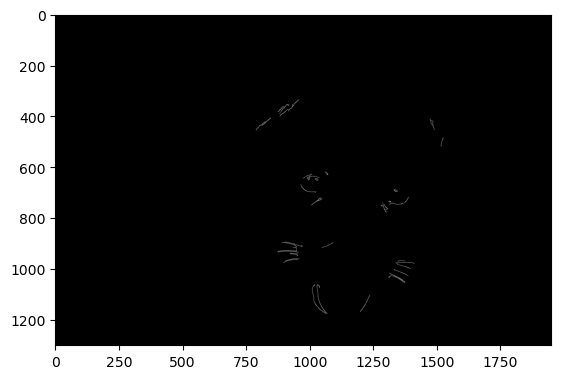

In [118]:
# Đọc ảnh gốc
img = cv2.imread('./images/00-puppy.jpg', 0)

# 1. Tiền xử lý lọc nhiễu bắt buộc bằng Gaussian Blur
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# 2. Áp dụng thuật toán Canny với cặp ngưỡng lý tưởng 1:2 hoặc 1:3
# Thấp hơn 50: loại bỏ; Cao hơn 150: giữ lại làm cạnh chắc chắn
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
plt.imshow(edges, cmap='gray')

### **3. Phát hiện Đường viền (Contour Detection)**
Đường viền (Contour) là một đường cong liên tục nối tất cả các điểm liên tiếp dọc theo một ranh giới có cùng màu sắc hoặc cường độ. Để đạt độ chính xác cao, Contour luôn được chạy trên Ảnh Nhị phân (sau khi đã qua Canny hoặc Thresholding).

Lệnh tìm: contours, hierarchy = cv2.findContours(img, mode, method)

Lệnh vẽ: cv2.drawContours(img, contours, -1, color, thickness)

Khái niệm Hierarchy (Hệ thống phân cấp): Khi một vật thể nằm bên trong một vật thể khác (ví dụ: một chiếc nhẫn nằm trên tờ giấy), OpenCV sẽ tổ chức các đường viền theo quan hệ Cha - Con (Parent - Child).

mode=cv2.RETR_EXTERNAL: Chỉ lấy các đường viền ngoài cùng (bỏ qua các lỗ bên trong).

mode=cv2.RETR_CCOMP: Lấy tất cả và phân chia thành 2 cấp: viền bao bên ngoài và viền của các lỗ thủng bên trong.

Tìm thấy tổng cộng: 1302 đường viền.


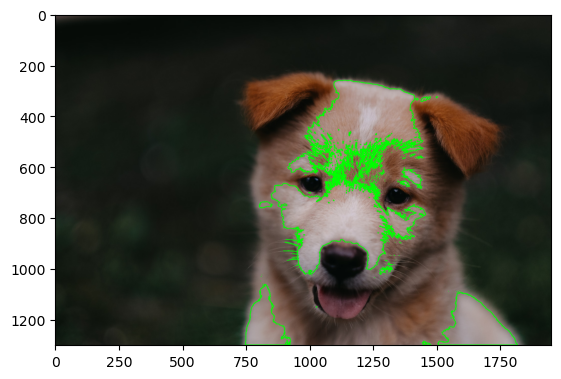

In [123]:
img = cv2.imread('./images/00-puppy.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Chuyển sang ảnh nhị phân
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2. Tìm kiếm đường viền (Lưu ý: hàm này làm thay đổi ma trận ảnh nhị phân đầu vào)
# RETR_TREE: Lấy toàn bộ cấu trúc phân cấp; CHAIN_APPROX_SIMPLE: Nén các điểm thừa để tiết kiệm RAM
contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# In ra tổng số vật thể tìm được
print(f"Tìm thấy tổng cộng: {len(contours)} đường viền.")

# 3. Vẽ lại TẤT CẢ đường viền lên ảnh gốc (Tham số thứ 3 bằng -1 có nghĩa là vẽ hết)
# Màu xanh lá (0, 255, 0), độ dày nét vẽ là 2
cv2.drawContours(img, contours, -1, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

### **4. Phát hiện Khuôn mặt bằng Haar Cascades (Face Detection)**
Trước khi Deep Learning bùng nổ, Haar Cascades (thuật toán Viola-Jones, 2001) là phương pháp tốt nhất trong việc phát hiện khuôn mặt với tốc độ nhanh.

- Thuật toán dựa trên các Đặc trưng Haar (Haar Features): Các ô chữ nhật đen trắng đặt cạnh nhau.
- Ví dụ đặc trưng vùng mắt: Vùng mắt thường tối hơn vùng sống mũi và gò má. Một ô chữ nhật đen (đặt ở mắt) và trắng (đặt ở gò má) sẽ tính hiệu số cường độ sáng. Nếu hiệu số này vượt qua một ngưỡng, máy tính nghi ngờ đó là khuôn mặt.

Để chạy thời gian thực, nó sử dụng:
- Ảnh tích lũy (Integral Image): Giúp tính tổng pixel trong ô chữ nhật chỉ bằng 4 phép toán.
- Cấu trúc tầng (Cascade): Ảnh được đưa qua một chuỗi các bộ lọc từ dễ đến khó. Nếu một vùng ảnh không qua được bộ lọc "Mắt" ở ngay tầng đầu tiên, nó bị loại ngay lập tức, máy tính không cần tốn tài nguyên tính toán các tầng sau (Mũi, Miệng...).

In [130]:
import cv2

# 1. Khởi tạo bộ phân loại tầng Haar Cascade (Tải file xml đi kèm thư viện OpenCV)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. Đọc ảnh và chuyển sang ảnh xám bắt buộc
img = cv2.imread('./images/face.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Tiến hành phát hiện đa quy mô khuôn mặt trên bức ảnh
# scaleFactor=1.2: Thu nhỏ ảnh 20% mỗi lần quét để phát hiện khuôn mặt ở xa/gần camera
# minNeighbors=5: Một vùng phải được ít nhất 5 khung chữ nhật trùng khớp mới được công nhận là mặt thật
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)
faces.shape

(1, 4)

1: phát hiện 1 mặt người trong ảnh

4: 4 thông số để định vị khung chữ nhật bao quanh khuôn mặt trên hệ trục tọa độ 2D của bức ảnh
- x: Tọa độ trục hoành (nằm ngang) của điểm ảnh ở góc trên cùng bên trái của khuôn mặt.
- y: Tọa độ trục tung (thẳng đứng) của điểm ảnh ở góc trên cùng bên trái của khuôn mặt.
- w: Chiều ngang của khuôn mặt kéo dài từ điểm x (tính bằng số lượng pixel).
- h: Chiều dọc của khuôn mặt kéo dài từ điểm y (tính bằng số lượng pixel).

In [133]:
face = faces[0]
x, y, w, h = face

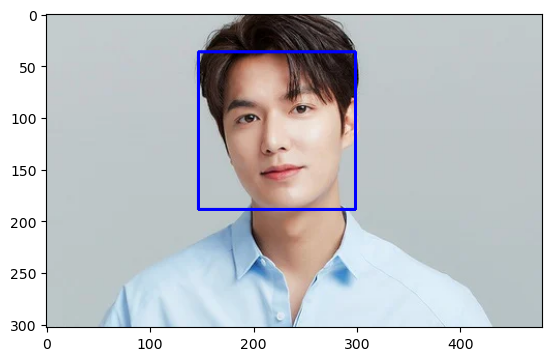

In [134]:
# Vẽ khung chữ nhật màu xanh dương (255, 0, 0) quanh khuôn mặt
cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))